In [19]:
import pandas as pd
import matplotlib.pyplot as plt

def view_data(file_path):
    # Read the data from the specified file path
    data = pd.read_csv(file_path)

    
    return data

file_path = "//Projetos2/Wrk/SIM-DATASUS/MICRODADOS/SIM-DATASUS-2020.csv"

data = view_data(file_path)

dictionary_colors = {
    'estado_civil': {'1': 'red', '2': 'blue', '3': 'green', '4': 'orange', '5': 'purple'},
    'sexo': {'1': 'cyan', '2': 'magenta'},
    'escolaridade': {'1': 'yellow', '2': 'brown', '3': 'pink', '4': 'gray', '5': 'olive'},
    'raca_cor': {'1': 'darkgreen', '2': 'navy', '3': 'yellow', '4': 'maroon', '5': 'red'}
}

dictionary_labels = {
    'estado_civil': {'1': 'Solteiro(a)', '2': 'Casado(a)', '3': 'Viúvo(a)', '4': 'Divorciado(a)', '5': 'União Consensual'},
    'sexo': {'1': 'Masculino', '2': 'Feminino'},
    'escolaridade': {'1': 'Nenhuma', '2': '1 a 3 anos', '3': '4 a 7 anos', '4': '8 a 11 anos', '5': '12 anos ou mais'},
    'raca_cor': {'1': 'Branca', '2': 'Preta', '3': 'Amarela', '4': 'Parda', '5': 'Indígena'}
}

def plot_data(df, x, y, kind='line', title=None, xlabel=None, ylabel=None, color=None, figsize=(10, 6)):
    """
    A generalist wrapper for matplotlib/pandas plotting.
    
    Parameters:
    - df: Pandas DataFrame
    - x: Column name for x-axis
    - y: Column name for y-axis (or list of names)
    - kind: 'line', 'bar', 'scatter', 'hist'
    """
    plt.figure(figsize=figsize)
    
    # Map 'kind' to specific matplotlib logic if necessary
    if kind == 'line':
        plt.plot(df[x], df[y], color=color, marker='o' if len(df) < 50 else None)
    elif kind == 'bar':
        plt.bar(df[x], df[y], color=color)
    elif kind == 'scatter':
        plt.scatter(df[x], df[y], color=color, alpha=0.6)
    
    # Customization
    plt.title(title or f'{kind.capitalize()} Plot: {y} vs {x}')
    plt.xlabel(xlabel or x)
    plt.ylabel(ylabel or y)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_subsector_categories(data, subsector, dictionary_colors, dictionary_labels, kind='line', figsize=(10, 6)):
    """
    Plot each subcategory of a subsector with its respective label and color.
    
    Parameters:
    - data: Pandas DataFrame containing the data
    - subsector: String name of the subsector column (e.g., 'sexo', 'raca_cor')
    - dictionary_colors: Dict mapping subsector to dict of {subcategory_id: color}
    - dictionary_labels: Dict mapping subsector to dict of {subcategory_id: label}
    - kind: Type of plot ('line', 'bar', 'scatter')
    - figsize: Figure size tuple
    """
    # Get unique subcategories for this subsector
    subcategories = sorted(data[subsector].dropna().unique())
    
    # Get colors and labels for this subsector
    colors = dictionary_colors.get(subsector, {})
    labels = dictionary_labels.get(subsector, {})
    
    # Create a plot for each subcategory
    for subcategory in subcategories:
        subcategory_str = str(int(subcategory))
        
        # Filter data for this subcategory
        df_filtered = data[data[subsector] == subcategory].groupby('idade').size().reset_index(name='total_obitos')
        
        # Get color and label
        color = colors.get(subcategory_str, None)
        label = labels.get(subcategory_str, f'Categoria {subcategory_str}')
        
        # Plot the data
        plt.figure(figsize=figsize)
        if kind == 'line':
            plt.plot(df_filtered['idade'], df_filtered['total_obitos'], color=color, label=label, linewidth=2)
        elif kind == 'bar':
            plt.bar(df_filtered['idade'], df_filtered['total_obitos'], color=color, label=label)
        elif kind == 'scatter':
            plt.scatter(df_filtered['idade'], df_filtered['total_obitos'], color=color, label=label, s=100, alpha=0.6)
        
        plt.title(f'Total Óbitos by Idade - {subsector.capitalize()}: {label}', fontsize=14, fontweight='bold')
        plt.xlabel('Idade', fontsize=12)
        plt.ylabel('Total Óbitos', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()


# Display by subsectors ['raca_cor', 'sexo', 'escolaridade', 'estado_civil']
subsectors = ['raca_cor', 'sexo', 'escolaridade', 'estado_civil']






C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:6: DtypeWarning: Columns (57,62,74,86) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(file_path)


C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


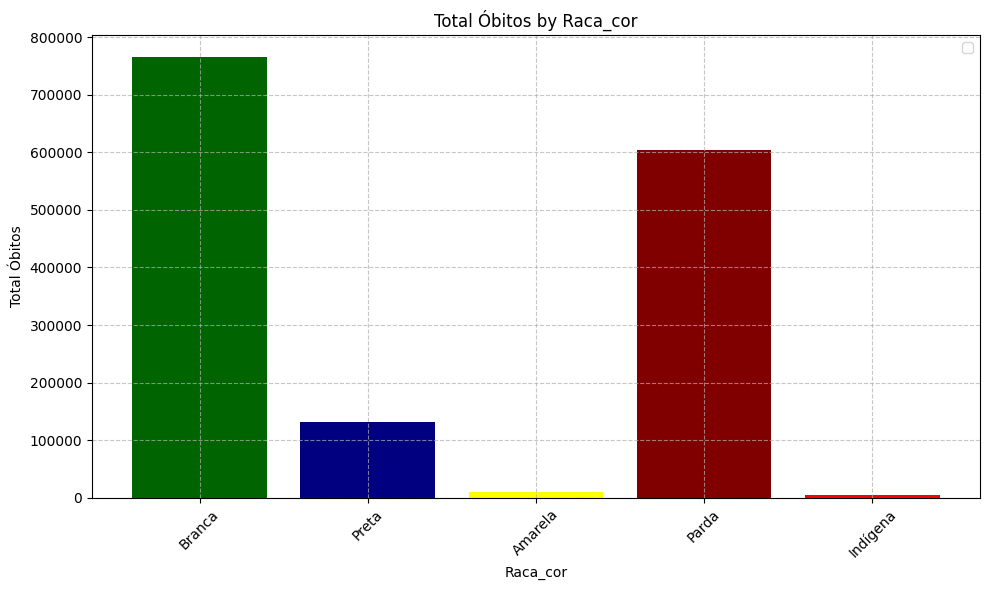

C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


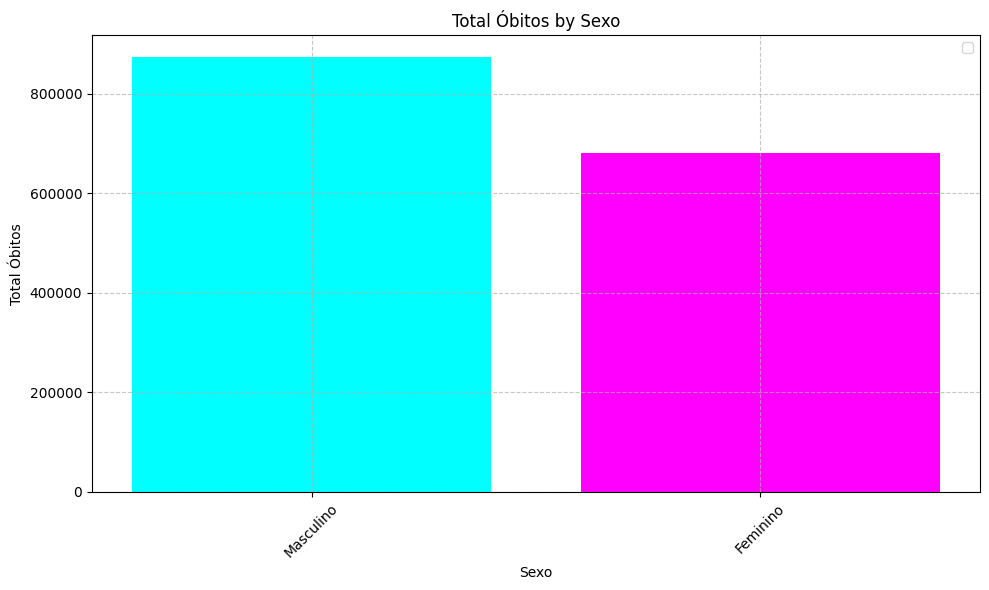

C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


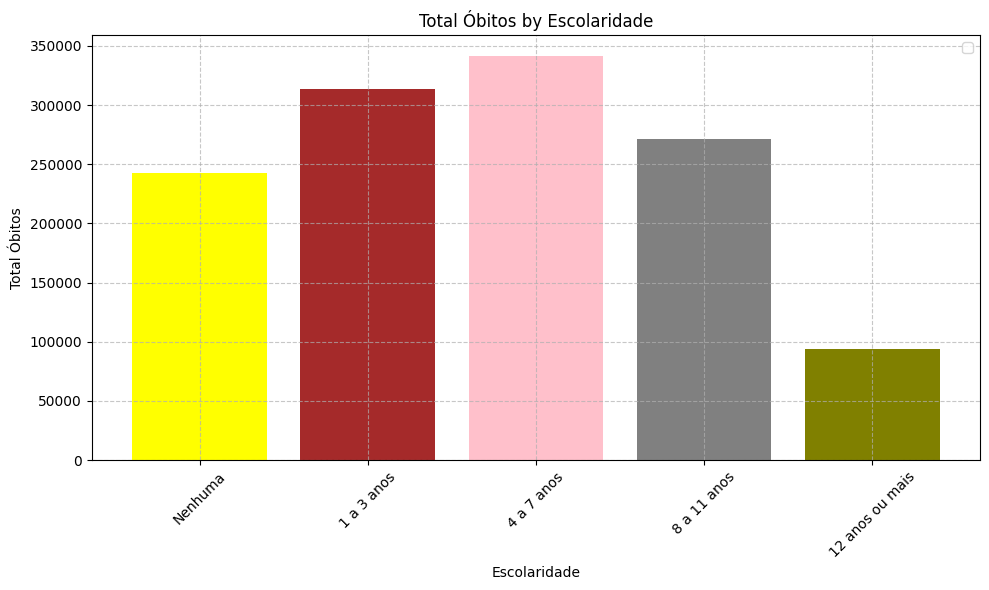

C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\2707929578.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


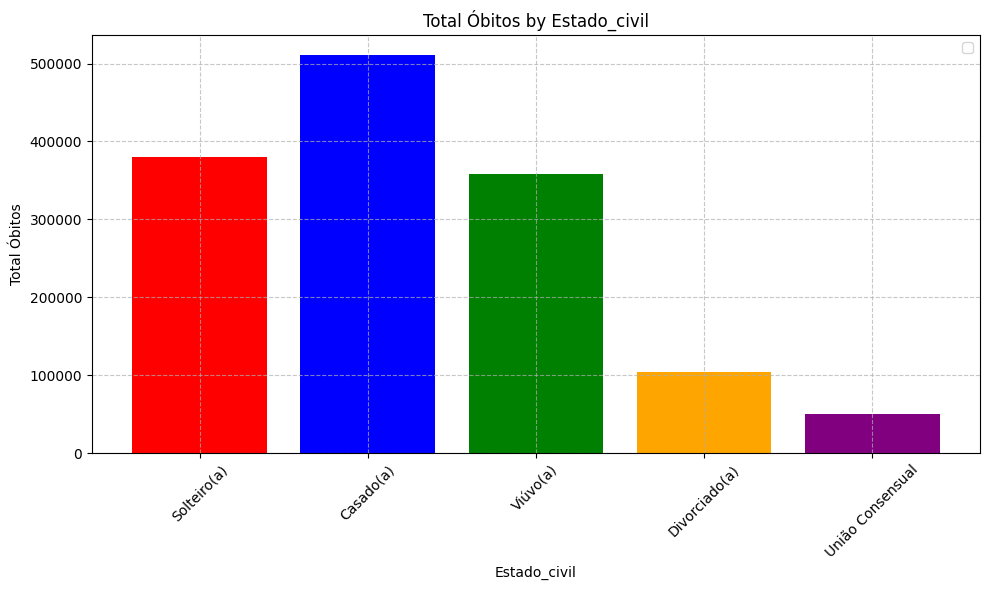

In [31]:
# Generalized function for any category
def total_deaths_by_category(data, category, dictionary_colors, dictionary_labels):
    """
    Calculate total deaths by category with labels and colors.
    
    Parameters:
    - data: Pandas DataFrame containing the data
    - category: String name of the category column (e.g., 'raca_cor', 'sexo')
    - dictionary_colors: Dict mapping category to dict of {id: color}
    - dictionary_labels: Dict mapping category to dict of {id: label}
    
    Returns:
    - DataFrame with category, total_obitos, colors, and labels
    """
    df_cat = data.groupby(category).size().reset_index(name='total_obitos')
    
    # Normalize keys to strings that match the dictionary keys.
    # Handles numeric floats like 1.0 -> '1' and preserves string keys like 'A'.
    def _normalize_key(v):
        if pd.isna(v):
            return '0'
        # float that is integer-like
        if isinstance(v, float):
            if v.is_integer():
                return str(int(v))
            return str(v)
        return str(v).strip()
    
    df_cat['cat_str'] = df_cat[category].apply(_normalize_key)
    # Map colors and labels, and ensure missing colors get a safe default
    df_cat['colors'] = df_cat['cat_str'].map(dictionary_colors.get(category, {})).fillna('gray')
    df_cat['label'] = df_cat['cat_str'].map(dictionary_labels.get(category, {}))
    
    # Remove rows with NaN labels (unmapped values)
    df_cat = df_cat.dropna(subset=['label'])
    
    return df_cat

total_deaths = {}

# Plot for every subsector
for subsector in subsectors:
    df_cat = total_deaths_by_category(data, subsector, dictionary_colors, dictionary_labels)

    total_deaths[subsector] = df_cat.set_index('label')['total_obitos'].to_dict()
    # Use the human-friendly label for the x axis and a cleaned color list (no NaN)
    plot_data(
        df_cat,
        x='label',
        y='total_obitos',
        kind='bar',
        title=f'Total Óbitos by {subsector.capitalize()}',
        xlabel=subsector.capitalize(),
        ylabel='Total Óbitos',
        color=df_cat['colors'].tolist(),
        figsize=(10, 6)
    )


C:\Users\Maia\AppData\Local\Temp\ipykernel_16648\2212196621.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


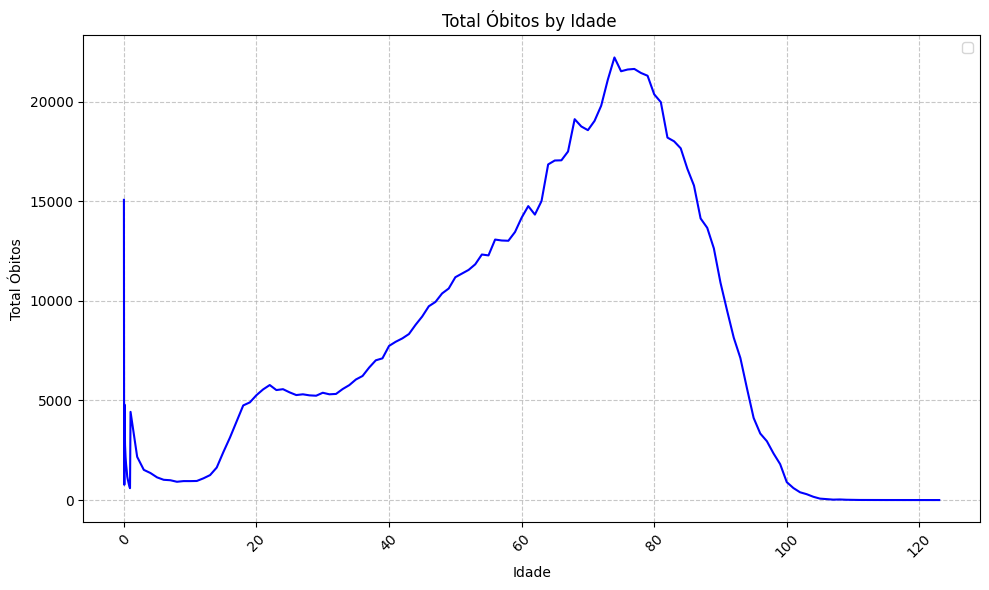

In [13]:
df_filtered = data.groupby('idade').size().reset_index(name='total_obitos')
plot_data(df_filtered, x='idade', y='total_obitos', kind='line', title=f'Total Óbitos by Idade ', xlabel='Idade', ylabel='Total Óbitos', color='blue', figsize=(10, 6))

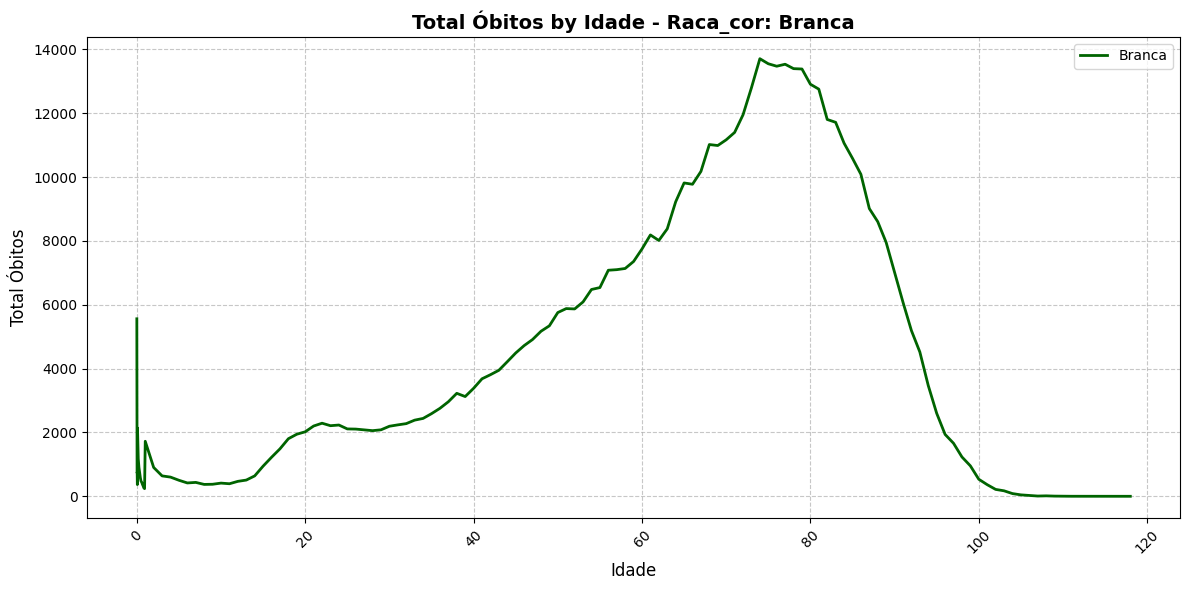

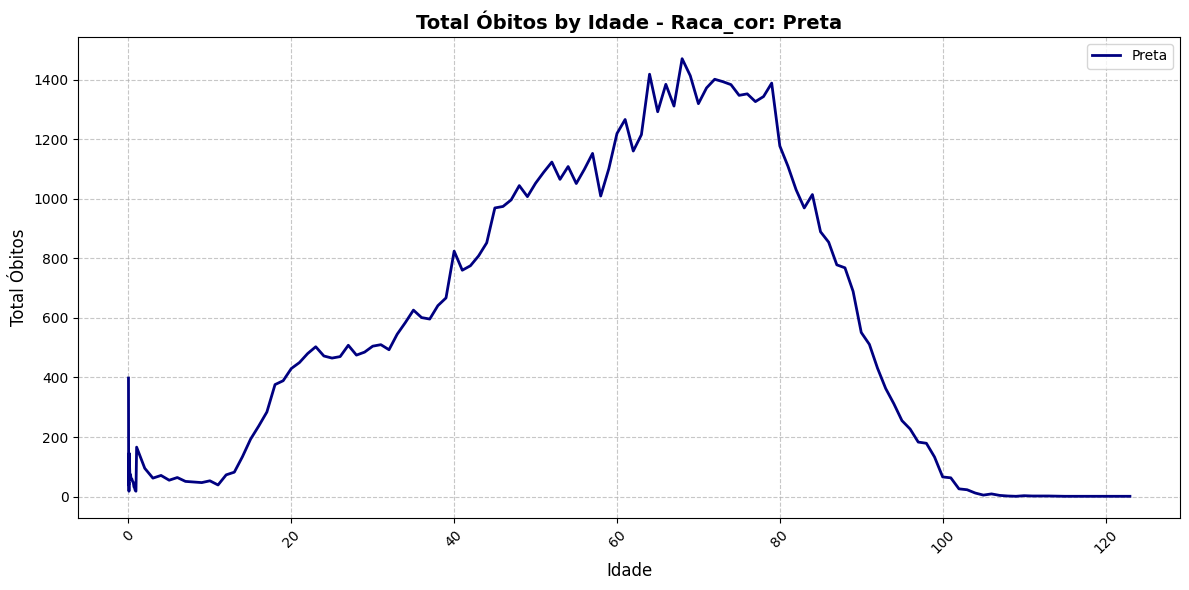

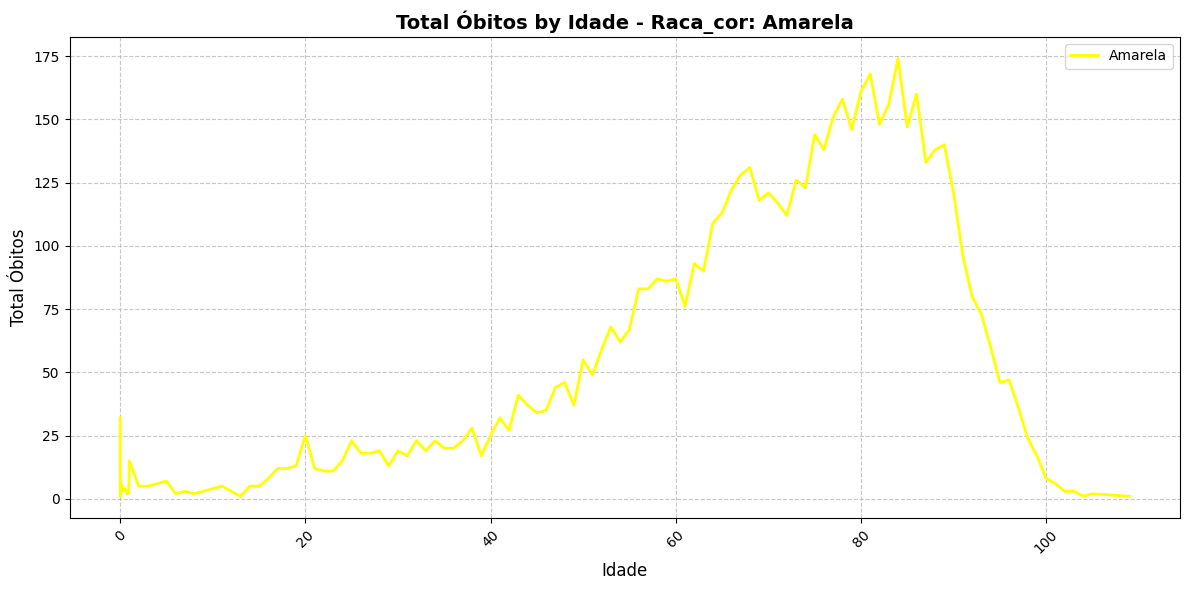

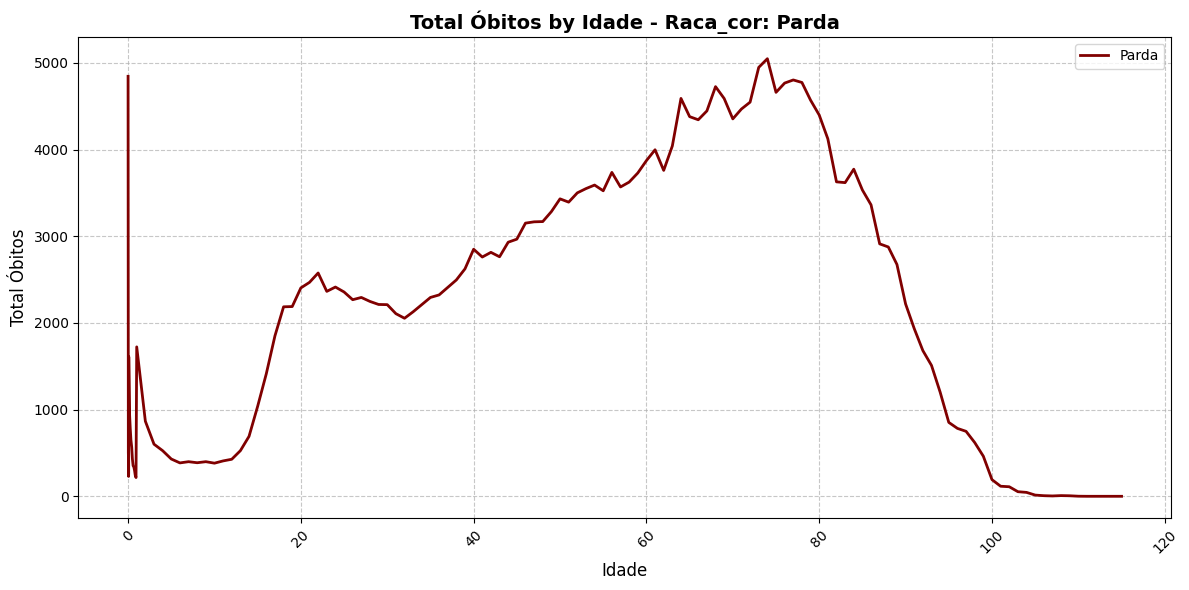

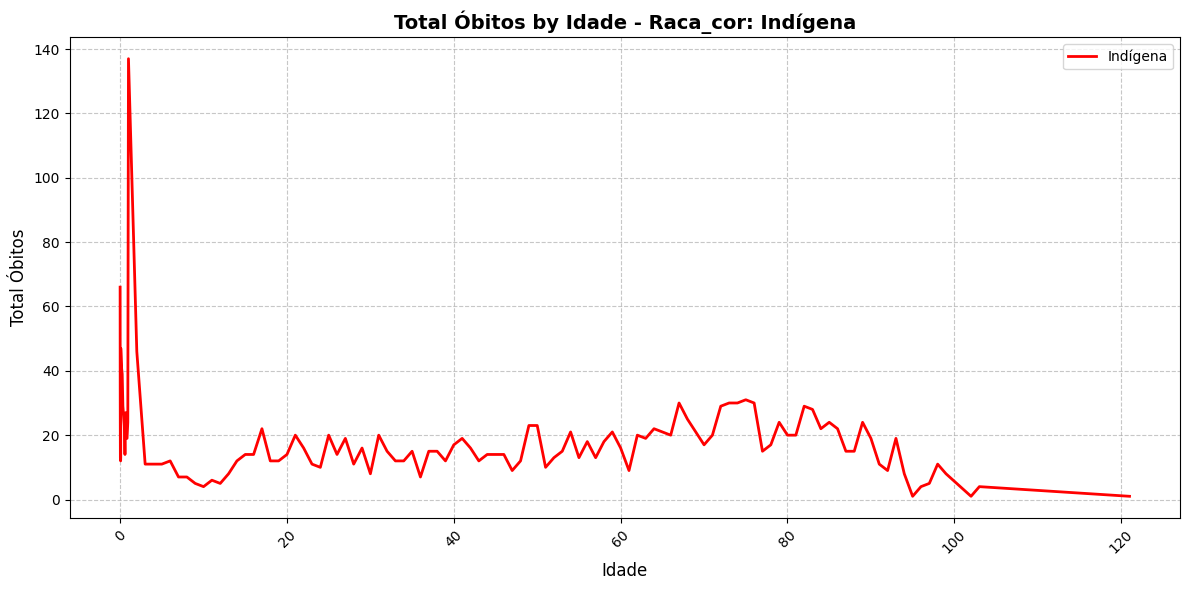

In [ ]:
plot_subsector_categories(data, subsector='raca_cor', dictionary_colors=dictionary_colors, dictionary_labels=dictionary_labels, kind='line', figsize=(12, 6))

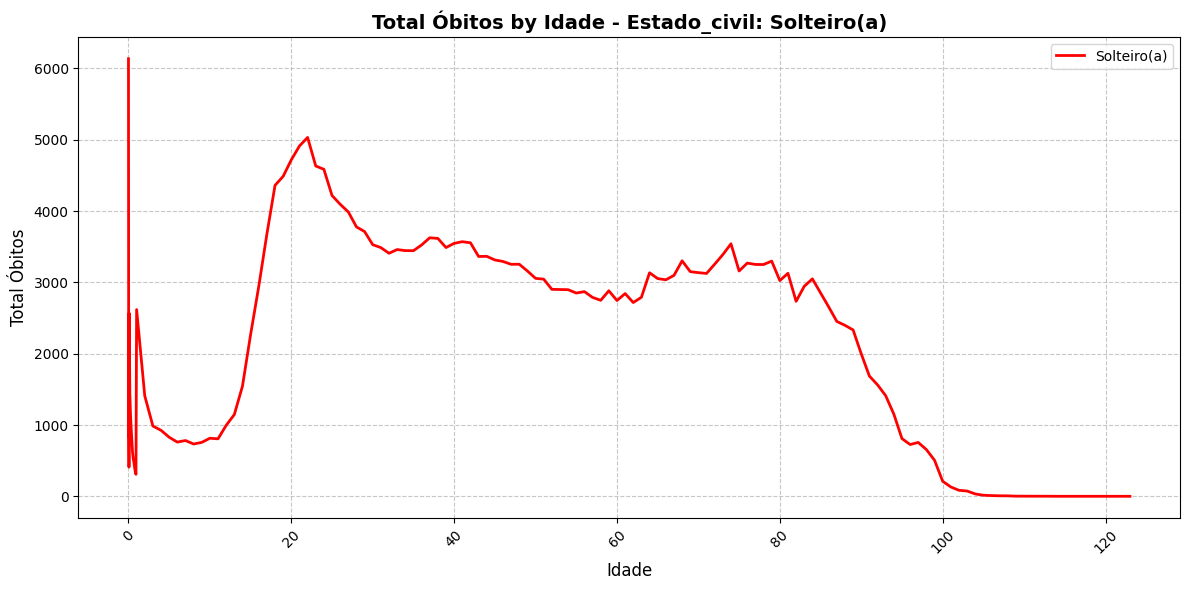

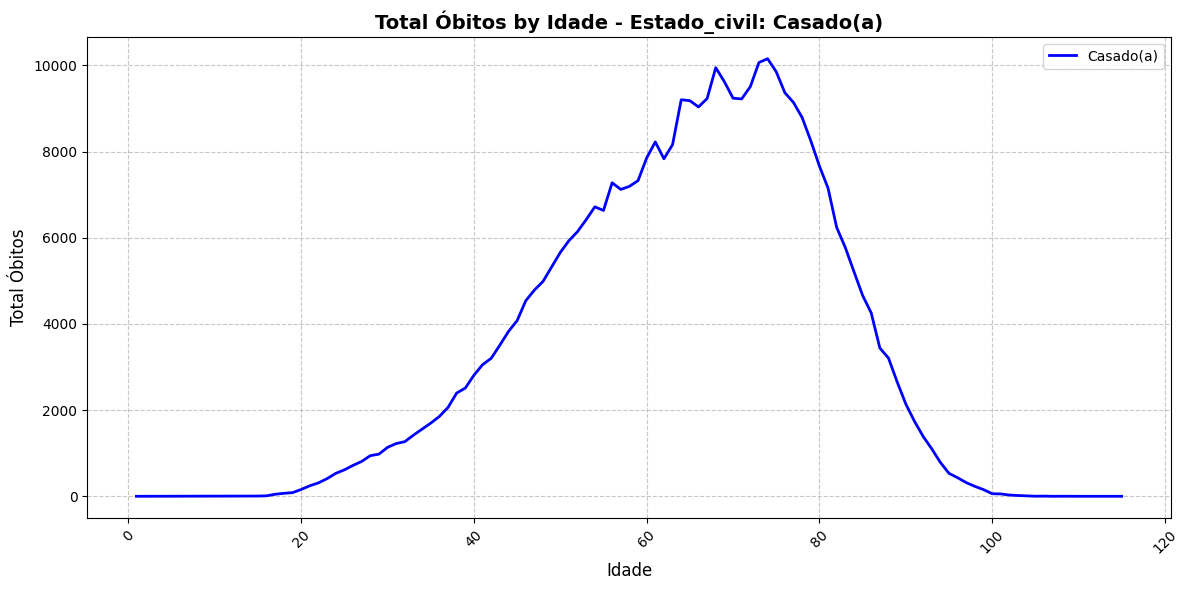

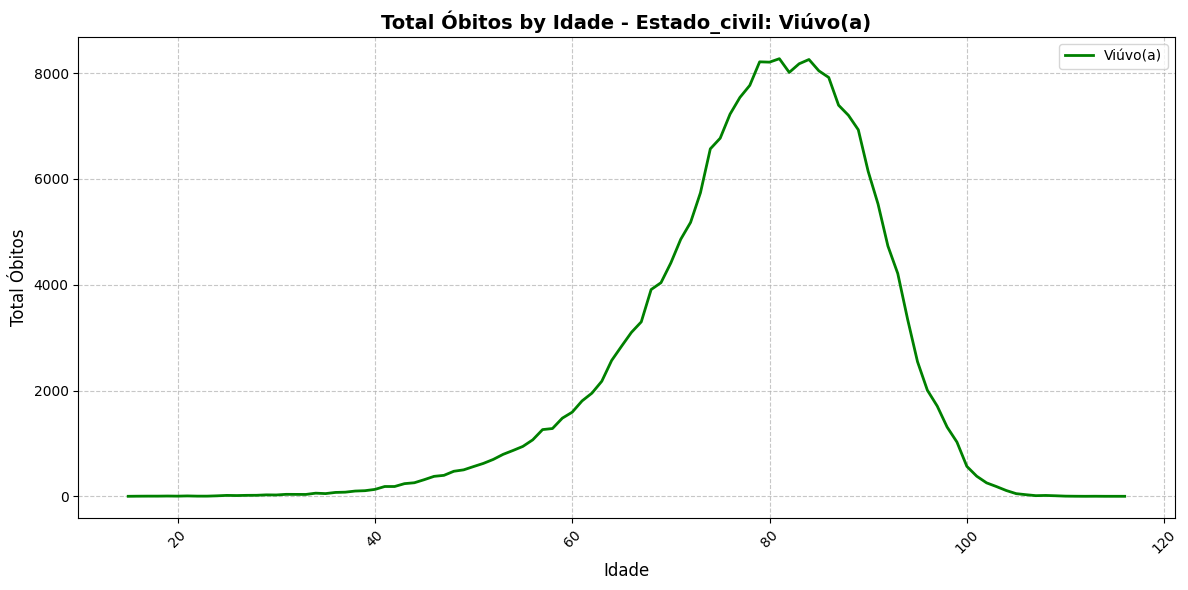

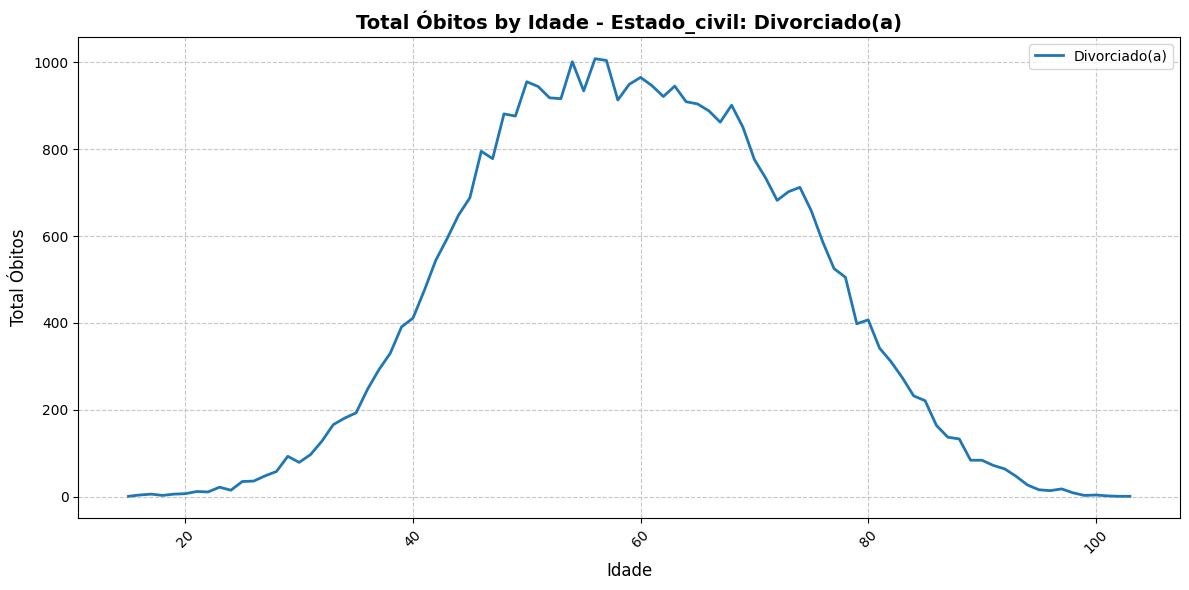

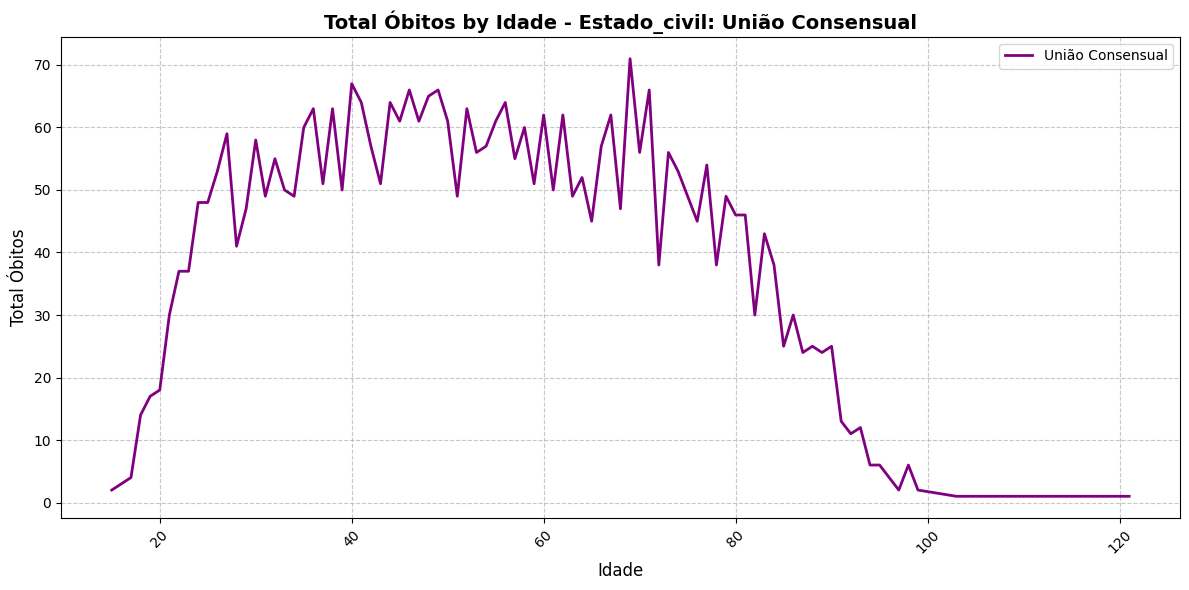

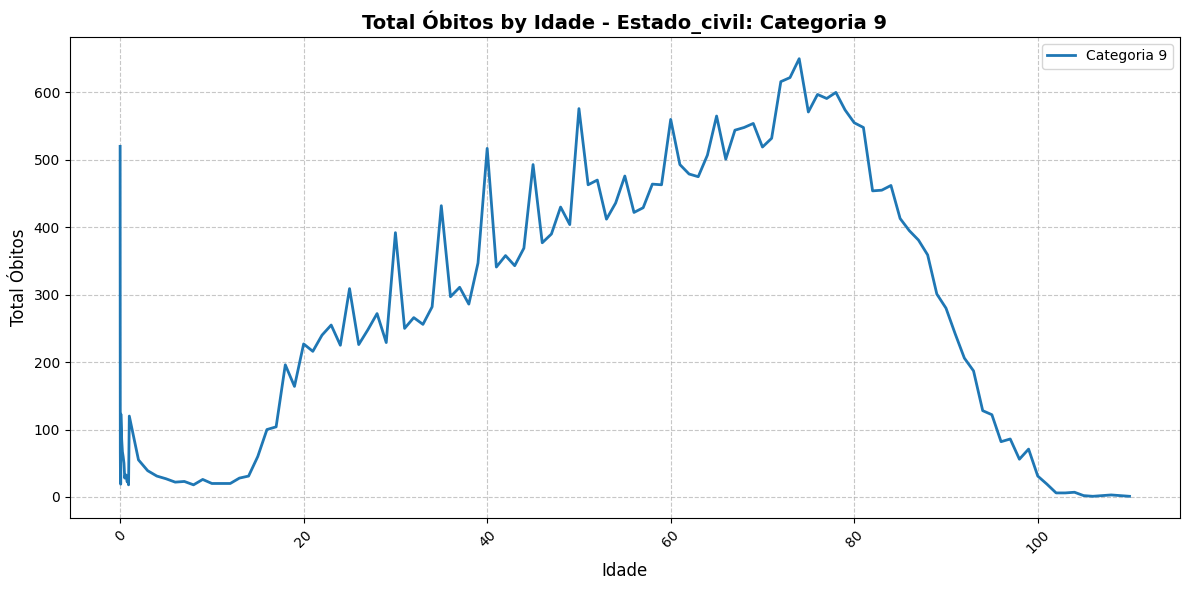

In [43]:
plot_subsector_categories(data, subsector='estado_civil', dictionary_colors=dictionary_colors, dictionary_labels=dictionary_labels, kind='line', figsize=(12, 6))

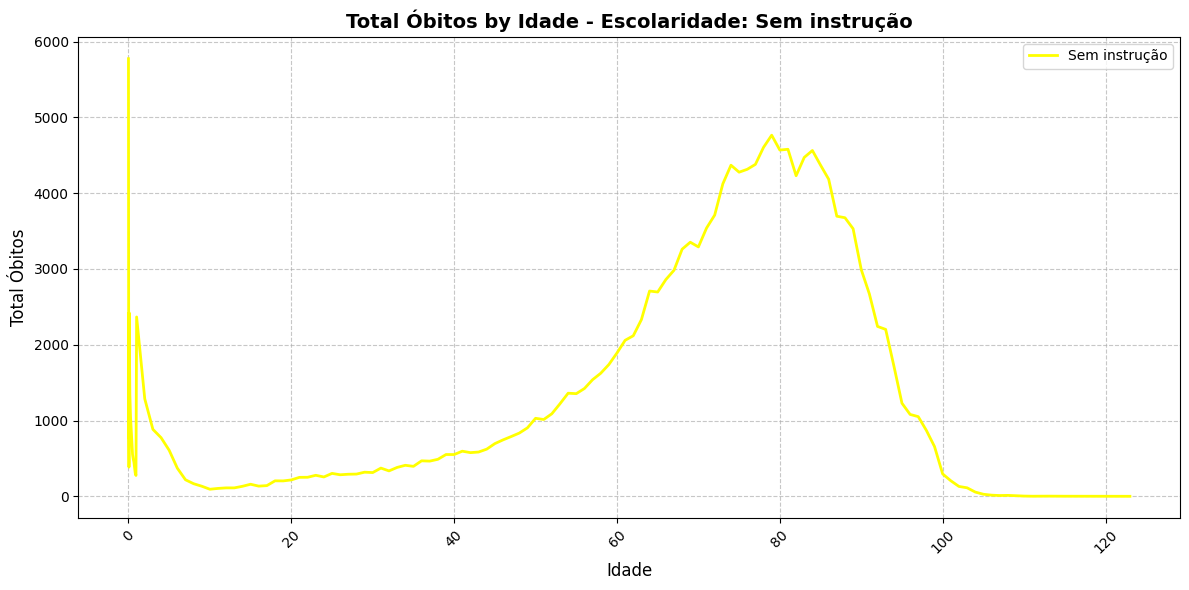

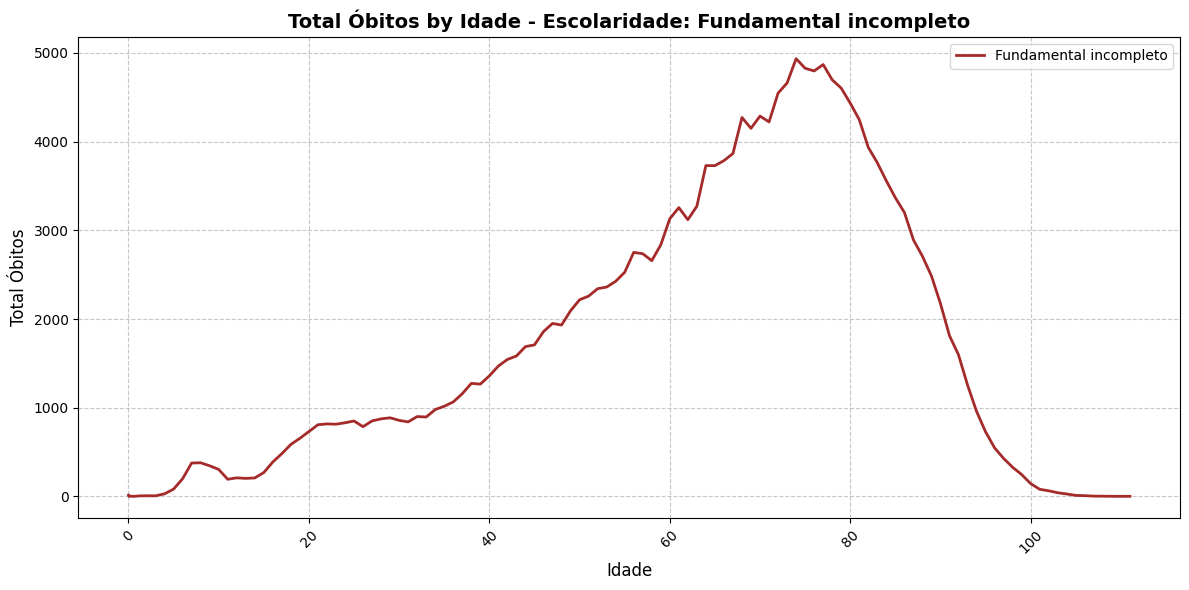

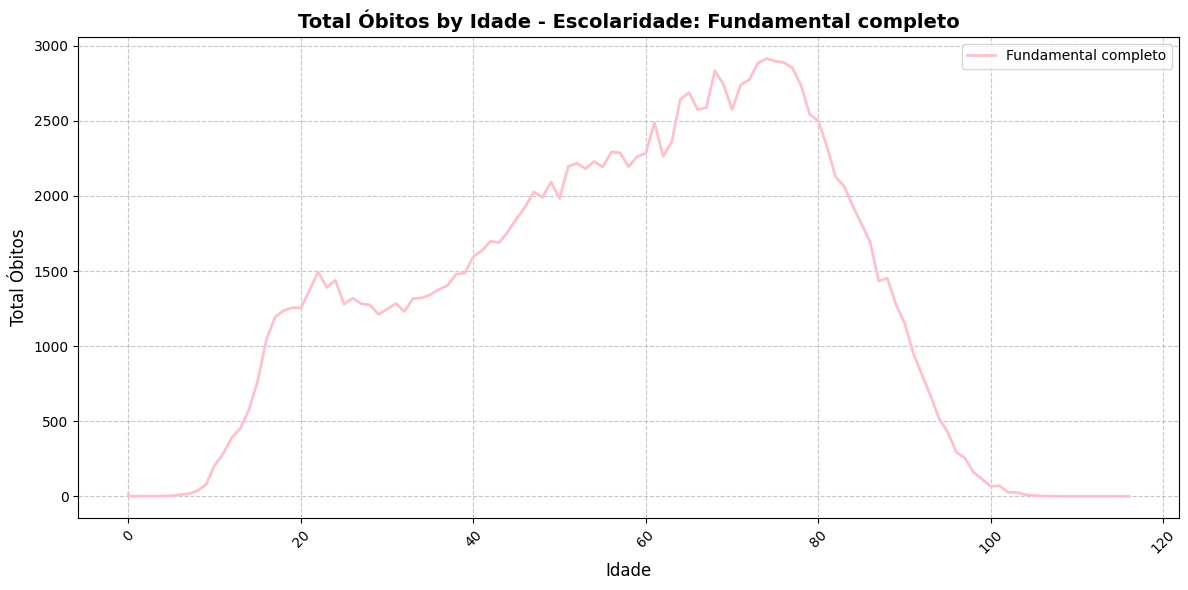

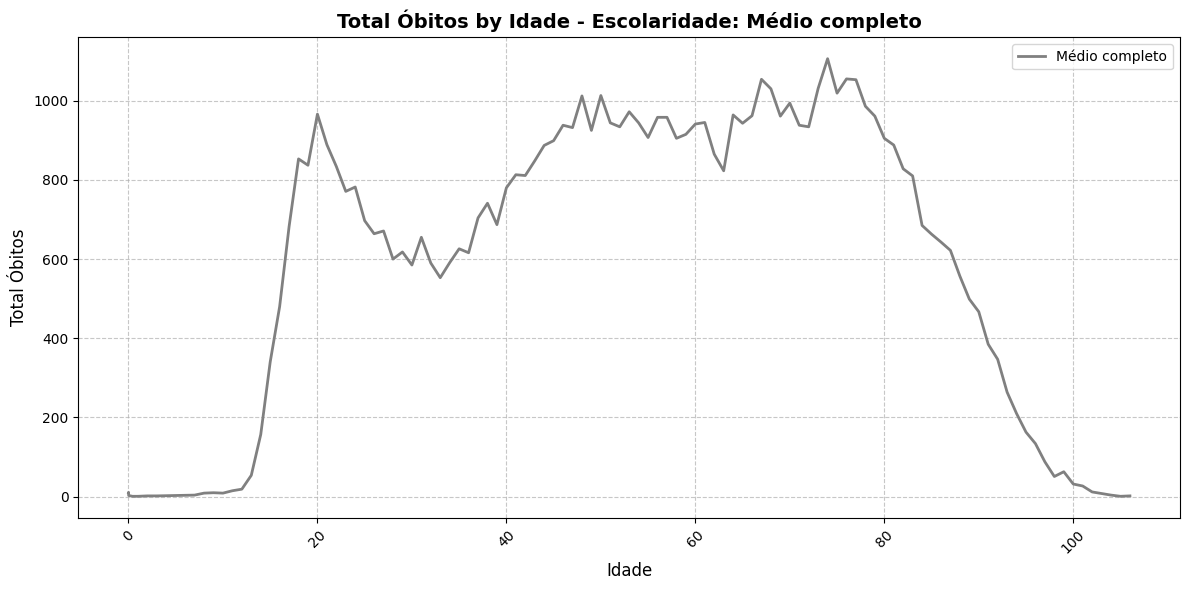

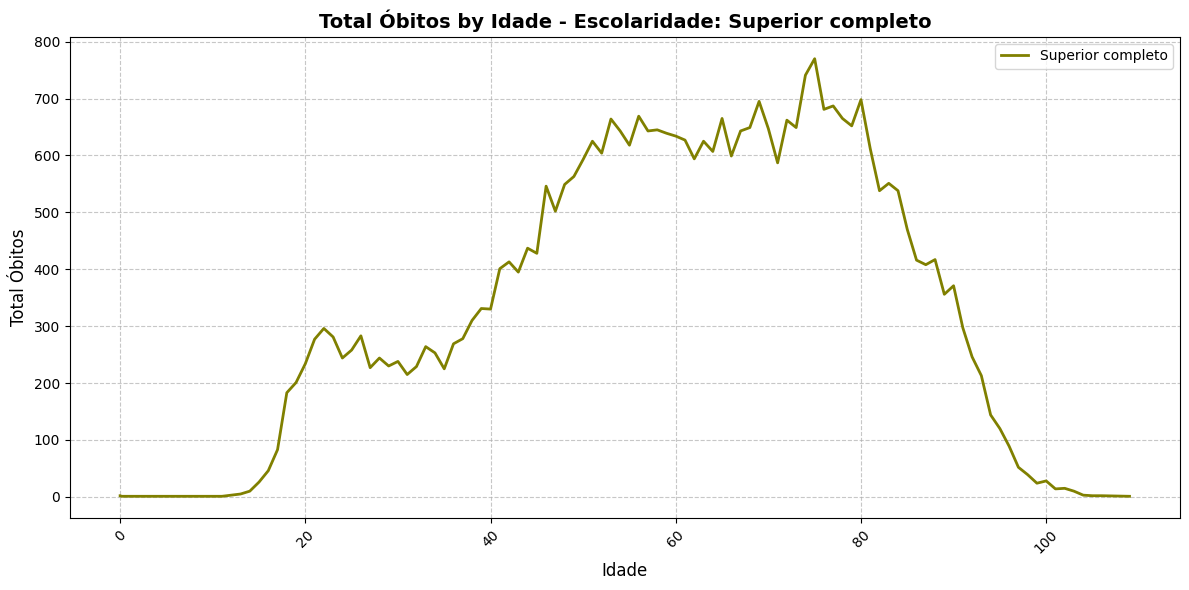

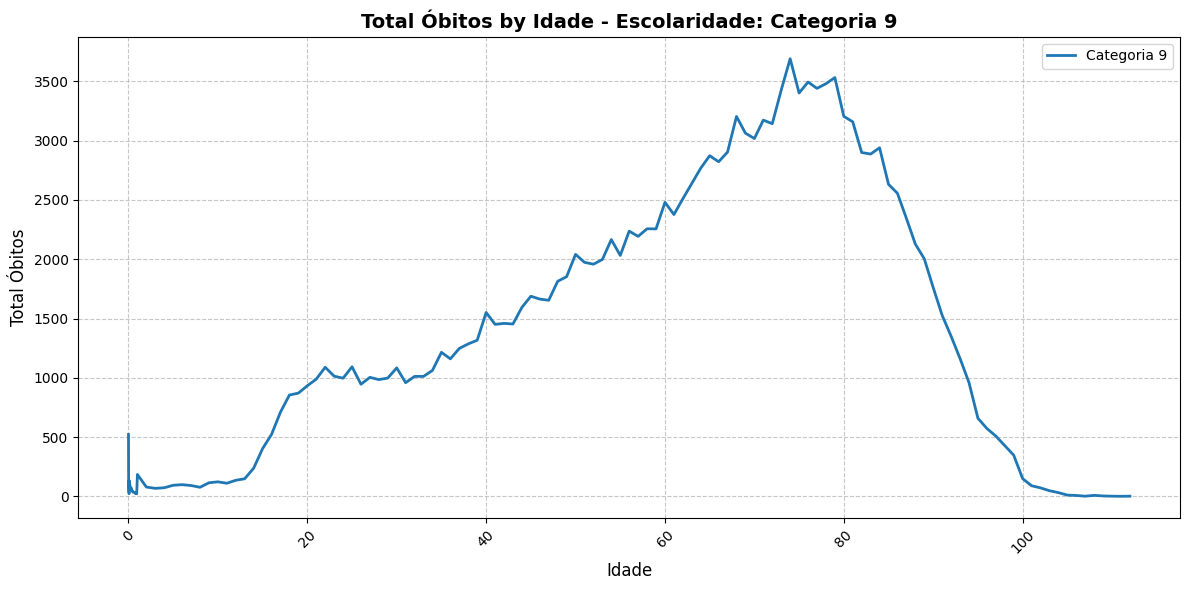

In [44]:
plot_subsector_categories(data, subsector='escolaridade', dictionary_colors=dictionary_colors, dictionary_labels=dicionary_labels, kind='line', figsize=(12, 6))

In [ ]:
def plot_subsector_total(data, subsector, dictionary_colors, dictionary_labels, kind='bar', figsize=(10, 6)):
    """
    Plot total deaths by a subsector with proper labels and colors.
    
    Parameters:
    - data: Pandas DataFrame containing the data
    - subsector: String name of the subsector column (e.g., 'raca_cor', 'sexo')
    - dictionary_colors: Dict mapping subsector to dict of {subcategory_id: color}
    - dictionary_labels: Dict mapping subsector to dict of {subcategory_id: label}
    - kind: Type of plot ('bar', 'line', 'scatter')
    - figsize: Figure size tuple
    """
    # Group by subsector and count
    df_sub = data.groupby(subsector).size().reset_index(name='total_obitos')
    
    # Convert to int first, then to string to match dictionary keys
    df_sub['sub_str'] = df_sub[subsector].fillna(0).astype(int).astype(str)
    df_sub['colors'] = df_sub['sub_str'].map(dictionary_colors.get(subsector, {}))
    df_sub['label'] = df_sub['sub_str'].map(dictionary_labels.get(subsector, {}))
    
    # Remove rows with NaN labels (unmapped values)
    df_sub = df_sub.dropna(subset=['label'])
    
    # Plot
    plot_data(df_sub, x='label', y='total_obitos', kind=kind, 
              title=f'Total Óbitos by {subsector.capitalize()}', 
              xlabel=subsector.capitalize(), 
              ylabel='Total Óbitos', 
              color=df_sub['colors'].tolist(), 
              figsize=figsize)

# Example usage - plot all subsectors
print("Plotting all subsectors...\n")

plot_subsector_total(data, 'raca_cor', dictionary_colors, dictionary_labels, kind='bar', figsize=(10, 6))
plot_subsector_total(data, 'sexo', dictionary_colors, dictionary_labels, kind='bar', figsize=(10, 6))
plot_subsector_total(data, 'estado_civil', dictionary_colors, dictionary_labels, kind='bar', figsize=(12, 6))
plot_subsector_total(data, 'escolaridade', dictionary_colors, dictionary_labels, kind='bar', figsize=(12, 6))

In [30]:
# Calculate mX by age group -- mx = D/N where D is the number of deaths in the age group and N is the population in that age group.

# For this, we need to read the population data by age group from a reliable source (e.g., IBGE) and merge it with our death data by age group. Then we can calculate mX and plot it.



censo_2022 = "//Projetos2/Wrk/SIM-DATASUS/IBGE/censo2022.csv"
censo_2020 = "//Projetos2/Wrk/SIM-DATASUS/IBGE/censo2020.csv"





In [32]:
total_deaths

{'raca_cor': {'Branca': 764700,
  'Preta': 132076,
  'Amarela': 9479,
  'Parda': 604570,
  'Indígena': 5363},
 'sexo': {'Masculino': 874167, 'Feminino': 682027},
 'escolaridade': {'Nenhuma': 242935,
  '1 a 3 anos': 313154,
  '4 a 7 anos': 341822,
  '8 a 11 anos': 271668,
  '12 anos ou mais': 94045},
 'estado_civil': {'Solteiro(a)': 380712,
  'Casado(a)': 510767,
  'Viúvo(a)': 357874,
  'Divorciado(a)': 104506,
  'União Consensual': 49867}}

In [106]:

def subsector_categories(data, subsector, dictionary_labels):
    """
    Plot each subcategory of a subsector with its respective label and color.
    
    Parameters:
    - data: Pandas DataFrame containing the data
    - subsector: String name of the subsector column (e.g., 'sexo', 'raca_cor')
    - dictionary_colors: Dict mapping subsector to dict of {subcategory_id: color}
    - dictionary_labels: Dict mapping subsector to dict of {subcategory_id: label}
    - kind: Type of plot ('line', 'bar', 'scatter')
    - figsize: Figure size tuple
    """
    # Get unique subcategories for this subsector
    subcategories = sorted(data[subsector].dropna().unique())

    # Dataframe to hold total deaths by age for each subcategory
    df_total_by_age = pd.DataFrame()
    
    # Create a plot for each subcategory
    for subcategory in subcategories:
        subcategory_str = str(int(subcategory))
        
        # Filter data for this subcategory
        df_filtered = data[data[subsector] == subcategory].groupby('idade').size().reset_index(name='total_obitos')
        
        # Dataframe to hold will receive total deaths by age for this subcategory
        df_total_by_age[subcategory_str] = df_filtered.set_index('idade')['total_obitos']
    
    # Relabel columns using dictionary_labels
    df_total_by_age.rename(columns=dictionary_labels.get(subsector, {}), inplace=True)
    
    # Reset index to convert 'idade' from index to column and convert to int
    df_total_by_age = df_total_by_age.reset_index()
    df_total_by_age['idade'] = df_total_by_age['idade'].astype(int)

    return df_total_by_age

In [108]:
# Display by subsectors ['raca_cor', 'sexo', 'escolaridade', 'estado_civil']
subsectors = ['raca_cor', 'sexo']

# Receive total deaths by age for each subsector category in a dictionary of DataFrames
dfs = {}

for subsector in subsectors:
    df_total_by_age = subsector_categories(data, subsector, dictionary_labels)
    
    dfs[subsector] = df_total_by_age

# Total deaths by age
df_filtered = data.groupby('idade').size().reset_index(name='total_obitos')
df_filtered['idade'] = df_filtered['idade'].astype(int)
dfs['total_by_age'] = df_filtered

In [107]:
# Plot subsector categories by age raca_cor
df = dfs['sexo'].sort_index()

plt.figure(figsize=(12, 6))
for column in df.columns:
    plt.plot(df.index, df[column], label=column)

plt.title('Total Óbitos by Idade and Raca/Cor')
plt.xlabel('Idade')
plt.ylabel('Total Óbitos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

AttributeError: 'function' object has no attribute 'sort_index'

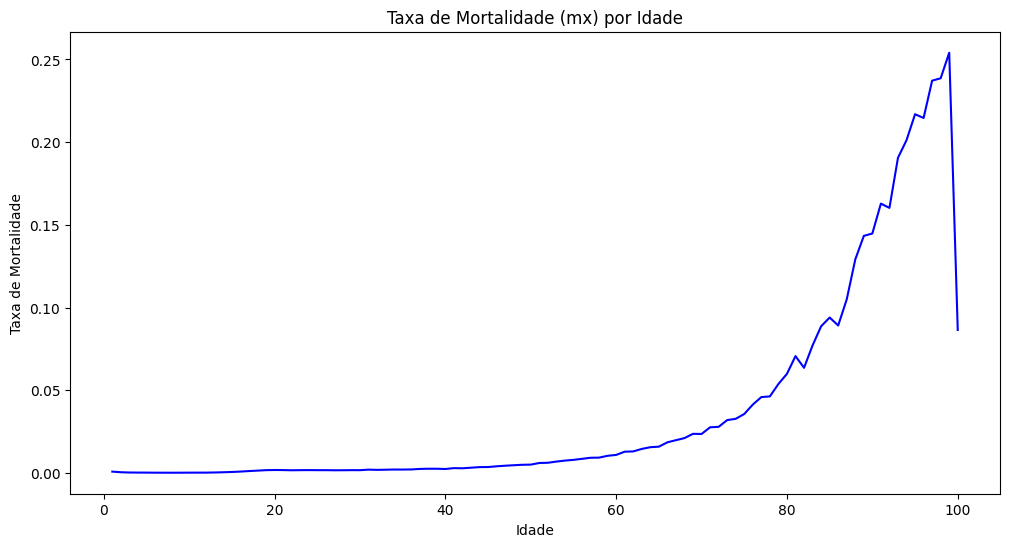

In [81]:
# Calculate mx by age group for the entire dataset
deaths_by_age = dfs['total_by_age'].reset_index()

censo_2022 = "//Projetos2/Wrk/SIM-DATASUS/IBGE/censo2022.csv"

censo_2022_df = pd.read_csv(censo_2022)

# Get only total column 
censo_2022_df[['Idade','Total']]

deaths_by_age.rename(columns={'idade': 'Idade Morte', 'total_obitos': 'Total Obitos'}, inplace=True)
censo_2022_df.rename(columns={'Idade': 'Idade Censo', 'Total': 'Total Populacao'}, inplace=True)

# Turning into int for merging
deaths_by_age['Idade Morte'] = deaths_by_age['Idade Morte'].astype(int)
censo_2022_df['Idade Censo'] = censo_2022_df['Idade Censo'].astype(int)

# Merge deaths by age with population by age
merged_df = pd.merge(deaths_by_age, censo_2022_df, left_on='Idade Morte', right_on='Idade Censo', how='inner')

# Calculate mx = D/N
merged_df['mx'] = merged_df['Total Obitos'] / merged_df['Total Populacao']

# Plot mx by age group
plt.figure(figsize=(12, 6))
plt.plot(merged_df['Idade Morte'], merged_df['mx'], color='blue')
plt.title('Taxa de Mortalidade (mx) por Idade')
plt.xlabel('Idade')
plt.ylabel('Taxa de Mortalidade')
plt.show()


In [82]:


def calculate_mx(deaths_by_age, population_by_age):
    """
    Calculate the mortality rate (mx) by age group.
    
    Parameters:
    - deaths_by_age: DataFrame with columns ['Idade', 'Total Obitos']
    - population_by_age: DataFrame with columns ['Idade', 'Total Populacao']
    
    Returns:
    - DataFrame with columns ['Idade', 'Total Obitos', 'Total Populacao', 'mx']
    """
    deaths_by_age.rename(columns={'idade': 'Idade', 'total_obitos': 'Total Obitos'}, inplace=True)
    population_by_age.rename(columns={'Idade': 'Idade', 'Total': 'Total Populacao'}, inplace=True)

    # Convert age columns to int for merging
    deaths_by_age['Idade'] = deaths_by_age['Idade'].astype(int)
    population_by_age['Idade'] = population_by_age['Idade'].astype(int)

    # Merge deaths by age with population by age
    merged_df = pd.merge(deaths_by_age, population_by_age, on='Idade', how='inner')
    
    # Calculate mx = D/N
    merged_df['mx'] = merged_df['Total Obitos'] / merged_df['Total Populacao']
    
    return merged_df[['Idade', 'Total Obitos', 'Total Populacao', 'mx']]


In [109]:
# Verificar estrutura e tipo de dados
print("Colunas:", dfs['raca_cor'].columns.tolist())
print("Tipos de dados:")
print(dfs['raca_cor'].dtypes)
print("\nPrimeiras linhas:")
dfs['raca_cor'].head(10)

Colunas: ['idade', 'Branca', 'Preta', 'Amarela', 'Parda', 'Indígena']
Tipos de dados:
idade         int64
Branca        int64
Preta       float64
Amarela     float64
Parda       float64
Indígena    float64
dtype: object

Primeiras linhas:


,idade,Branca,Preta,Amarela,Parda,Indígena
0,0,2686,188.0,19.0,4347.0,140.0
1,0,1974,138.0,9.0,2884.0,69.0
2,0,868,65.0,4.0,1130.0,29.0
3,0,447,32.0,2.0,541.0,9.0
4,0,442,29.0,2.0,507.0,14.0
5,0,323,18.0,3.0,379.0,10.0
6,0,214,19.0,2.0,224.0,7.0
7,0,229,14.0,NaN,277.0,5.0
8,0,1188,87.0,2.0,1547.0,60.0
9,0,557,48.0,2.0,665.0,24.0


In [92]:
censo_2022 = "//Projetos2/Wrk/SIM-DATASUS/IBGE/censo2022.csv"
censo_2022_df = pd.read_csv(censo_2022)

# Define by raca_cor

raca_cor = ['Branca', 'Preta', 'Amarela', 'Parda', 'Indígena']

for raca in raca_cor:
    calculate_mx(dfs['raca_cor'], censo_2022_df[['Idade', raca]])

C:\Users\Maia\AppData\Local\Temp\ipykernel_34356\790182994.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population_by_age.rename(columns={'Idade': 'Idade', 'Total': 'Total Populacao'}, inplace=True)


KeyError: 'Idade'